<a href="https://colab.research.google.com/github/paarthbamb/dataScience/blob/main/Unit6/Copy_of_Unit6ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 6 Exercises: Is my model good?

#### Over and Under fitting, Model Visualization, and Model/Variable Selection Concepts

These exercises are meant to get you to think about the model and variable selection process, and consider how we determine if a model is "good".

**Task1**:

Does elpd_loo mean anything if we only have one model?

No, because elpd_loo is  useful if we are trying to compare two or more models. In this case a greater elpd_loo would mean a better model. Elpd_loo is just a comparison between two models.

**Task2**:

Describe overfitting, in the context of this course

In the context of this course, overfitting means when a model takes too many data points into account, causing the mdoel to make predictions that aren't accurate to the data set.

**Task3**:

How do we mitigate overfitting?

We should have weak priors. Additionally, we should use a relatively small number of variables in our model. Using less variables would make the model not able to take into account random points of data from the data set, which mitigates the effects of overfitting.

**Task4**:

How do we mitigate underfitting?

Mitigating underfitting can be done by utilizing elpd_loo to choose a model that uses the right amount of data.

**Task5**:

Why would we want more than one predictor in a model?

If there are multiple factors which play into the dependent variable, we would choose to use more than one predictor. An example of this is the winner of an NFL game could be determined by the players' skill level and the weather.

**Task6**:

Can we have too many predictors? How would we know?

Yes. It can cause overfitting and a problem where the model won't be able to predict outside of the observed data.

**Task7**:

What is variable selection, and how does it work?

Variable selection is when you compare the elpd_loos of differend models and see which one is better to use the predictors from that comparison. This is to see which variables you want to use in your model i.e. variable selection.

**Task8**:

Describe the differences and similarities between the following three models: linear regression with two predictors, one of which is a categorical variable:

- adding the variables in the model, as is standard.
- using that categorical variable as a hierarchy upon the other predictor variable.
- adding the variables, plus the categorical variable's interaction with the other variable.

The models are the same in the way that all the regressions are linear. The slopes are the same in the first model between groups while in the second one every group has a differing relationship. Same thing with the third model, as the predictor affects each group differently.

**Task9**:

How do we visualize multiple linear regression models? Can we visualize the entire model, all at once?

Visualizing the model can be done with making it into 2D using multiple lines. I don't think we will be able to visualize the entire model at once as it's pretty hard to visualize more than 3 dimensions based on what I learned in multi.

**Task10**:

Compare the following linear models that all use the basketball data to predict field goal percentage:

- predictors free throw percentage and position (with position as a categorical predictor)
- predictors free throw percentage and position (with position as a hierarchy)
- predictors free throw percentage and position (with position interacting with frew throw percentage)
- predictors free throw percentage, position, 3 point attempts, and interactions between all three predictors
- predictors free throw percentage, position, 3 point attempts, with an interaction between 3 point attempts and postion.

using ```az.compare()``` and ```az.plot_compare()```, or an equivalent method using LOO (elpd_loo).

You may use the following two code blocks to load and clean the data.

In [ ]:
import numpy as np
import pandas as pd
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns
!pip install bambi
import bambi as bmb

In [2]:
import pandas as pd
#have to drop incomplete rows, so that bambi will run
bb = pd.read_csv(
    'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/basketball2324.csv'
    ).dropna()

In [3]:
#only look at players who played more than 600 minutes
#which is 20 min per game, for 30 games
bb = bb.query('MP > 600')
#remove players who never missed a free throw
bb = bb.query('`FT%` != 1.0')
#filter out the combo positions. This will make it easier to read the graphs
bb = bb.query("Pos in ['C','PF','SF','SG','PG']")
#gets rid of the annoying '%' sign
bb.rename(columns={"FT%":"FTp","FG%":"FGp"}, inplace=True)

In [ ]:

model_basketball = bmb.Model("`FGp` ~ `FTp` + Pos", data=bb)
idata_basketball = model_basketball.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

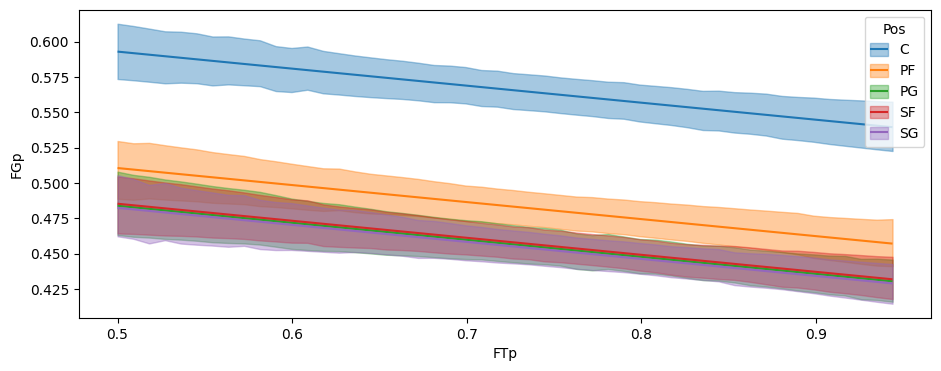

In [5]:
bmb.interpret.plot_predictions(model_basketball,
                               idata_basketball,
                                ["FTp",  "Pos"], fig_kwargs={"figsize":(11, 4)})


In [ ]:
model_basketball_h = bmb.Model("`FGp` ~ (`FTp`|Pos)", data=bb)
idata_basketball_h = model_basketball_h.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

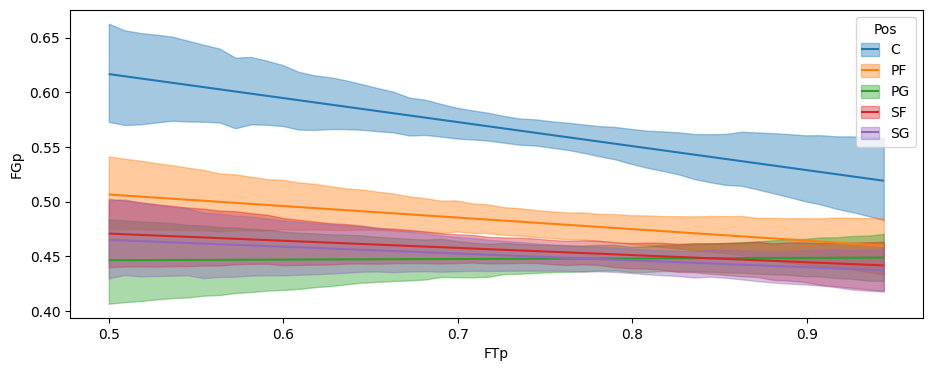

In [9]:
bmb.interpret.plot_predictions(model_basketball_h,
                               idata_basketball_h,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)})

In [ ]:
model_bb_inter = bmb.Model("`FGp` ~ `FTp` + Pos + `FTp`:Pos", data=bb)
idata_bb_inter = model_bb_inter.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

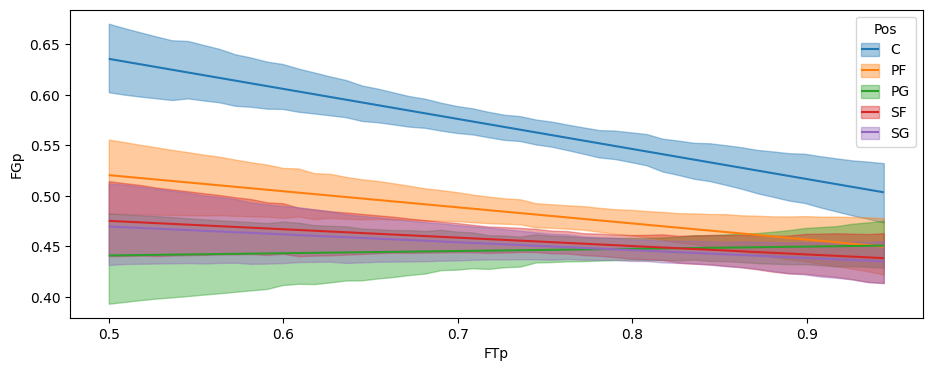

In [11]:
bmb.interpret.plot_predictions(model_bb_inter,
                               idata_bb_inter,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)})

In [12]:
model_bb_inter4 = bmb.Model("`FGp` ~ `FTp` + `3PA` + Pos + `FTp`:`3PA` + `FTp`:Pos + `3PA`:Pos + `3PA`:`FTp`:`Pos`", data=bb)
idata_bb_inter4 = model_bb_inter4.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 6 Axes>,
 array([[<Axes: title={'center': 'Pos = C'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = PF'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = PG'}, xlabel='FTp', ylabel='FGp'>],
        [<Axes: title={'center': 'Pos = SF'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = SG'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: xlabel='FTp', ylabel='FGp'>]], dtype=object))

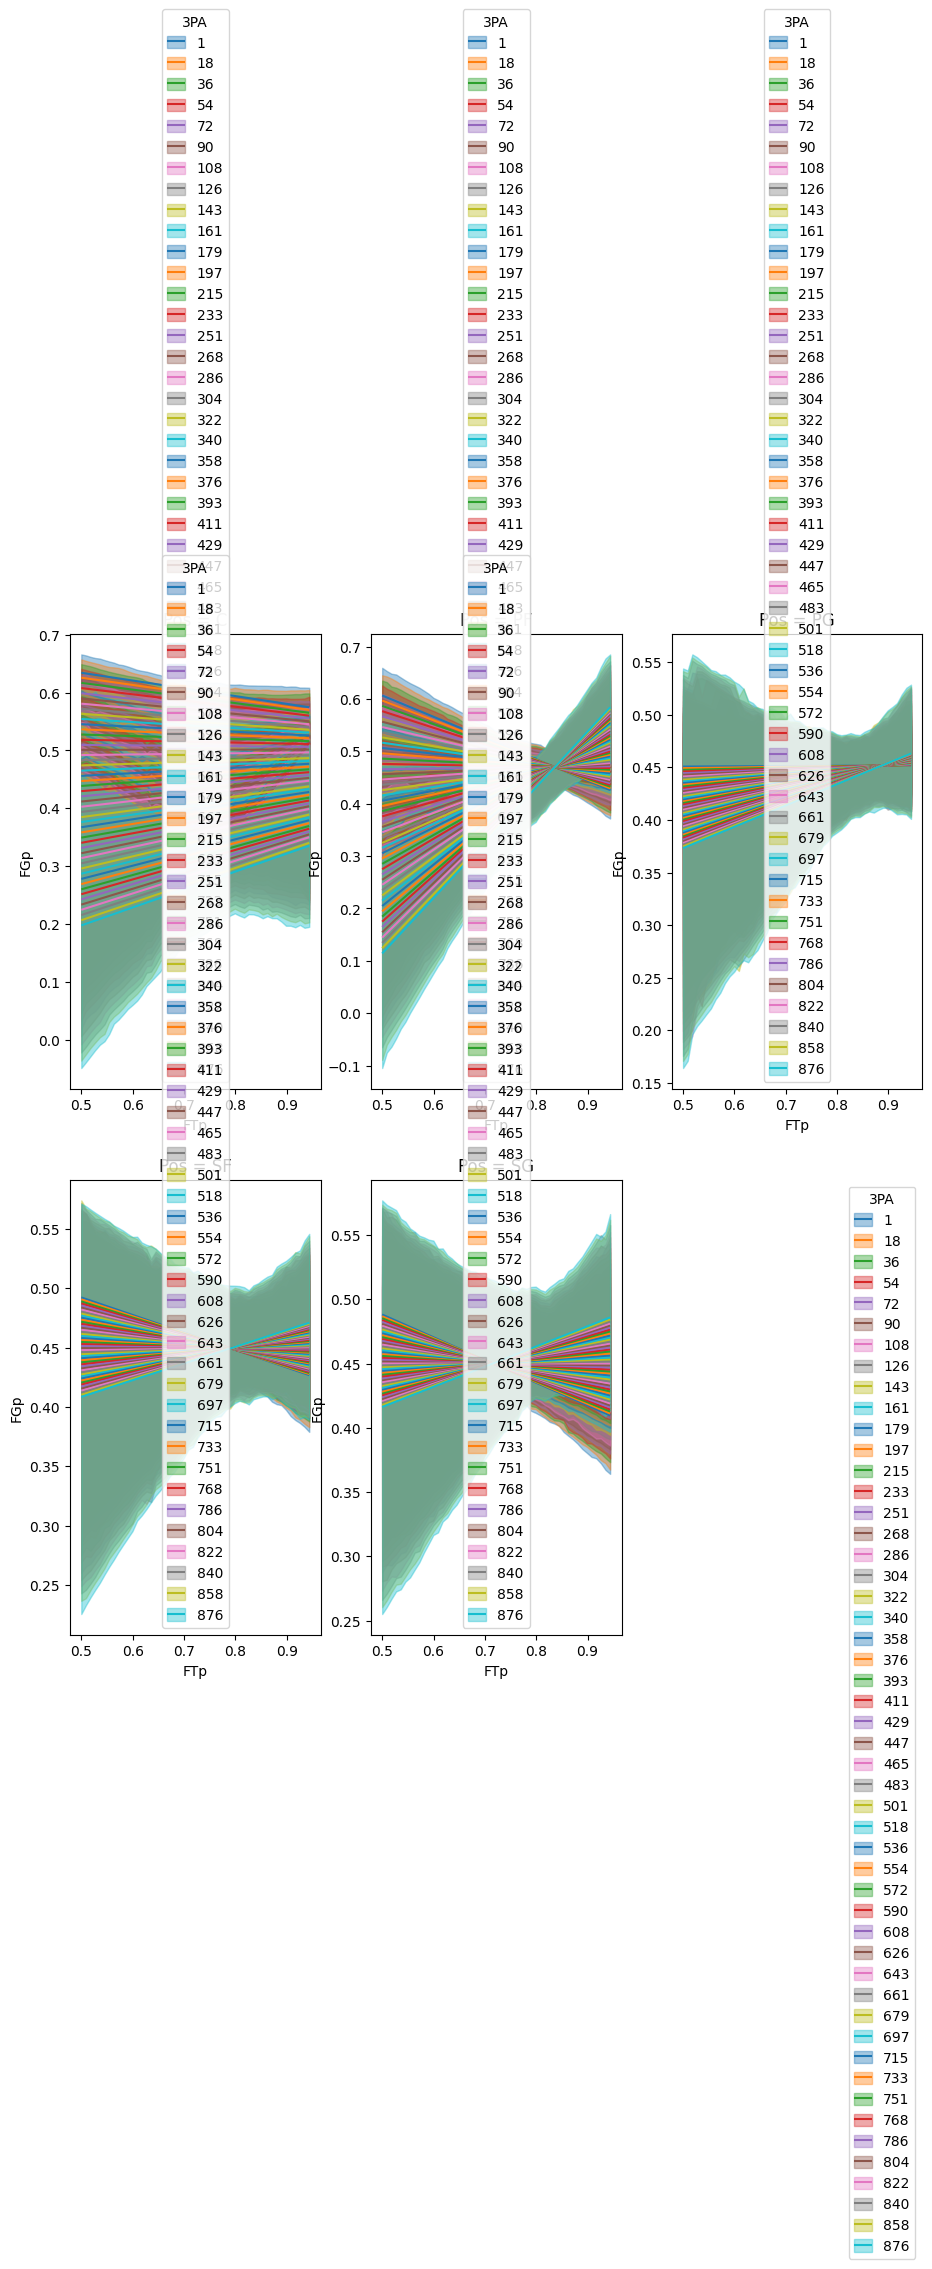

In [13]:
bmb.interpret.plot_predictions(model_bb_inter4,
                               idata_bb_inter4,
                               ["FTp","3PA", "Pos"],
                               fig_kwargs={"figsize":(11, 13)})#,
                               #legend=False)

In [ ]:
model_bb_inter5 = bmb.Model("`FGp` ~ `FTp` + `3PA` + Pos + Pos:`3PA`", data=bb)
idata_bb_inter5 = model_bb_inter5.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 6 Axes>,
 array([[<Axes: title={'center': 'Pos = C'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = PF'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = PG'}, xlabel='FTp', ylabel='FGp'>],
        [<Axes: title={'center': 'Pos = SF'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = SG'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: xlabel='FTp', ylabel='FGp'>]], dtype=object))

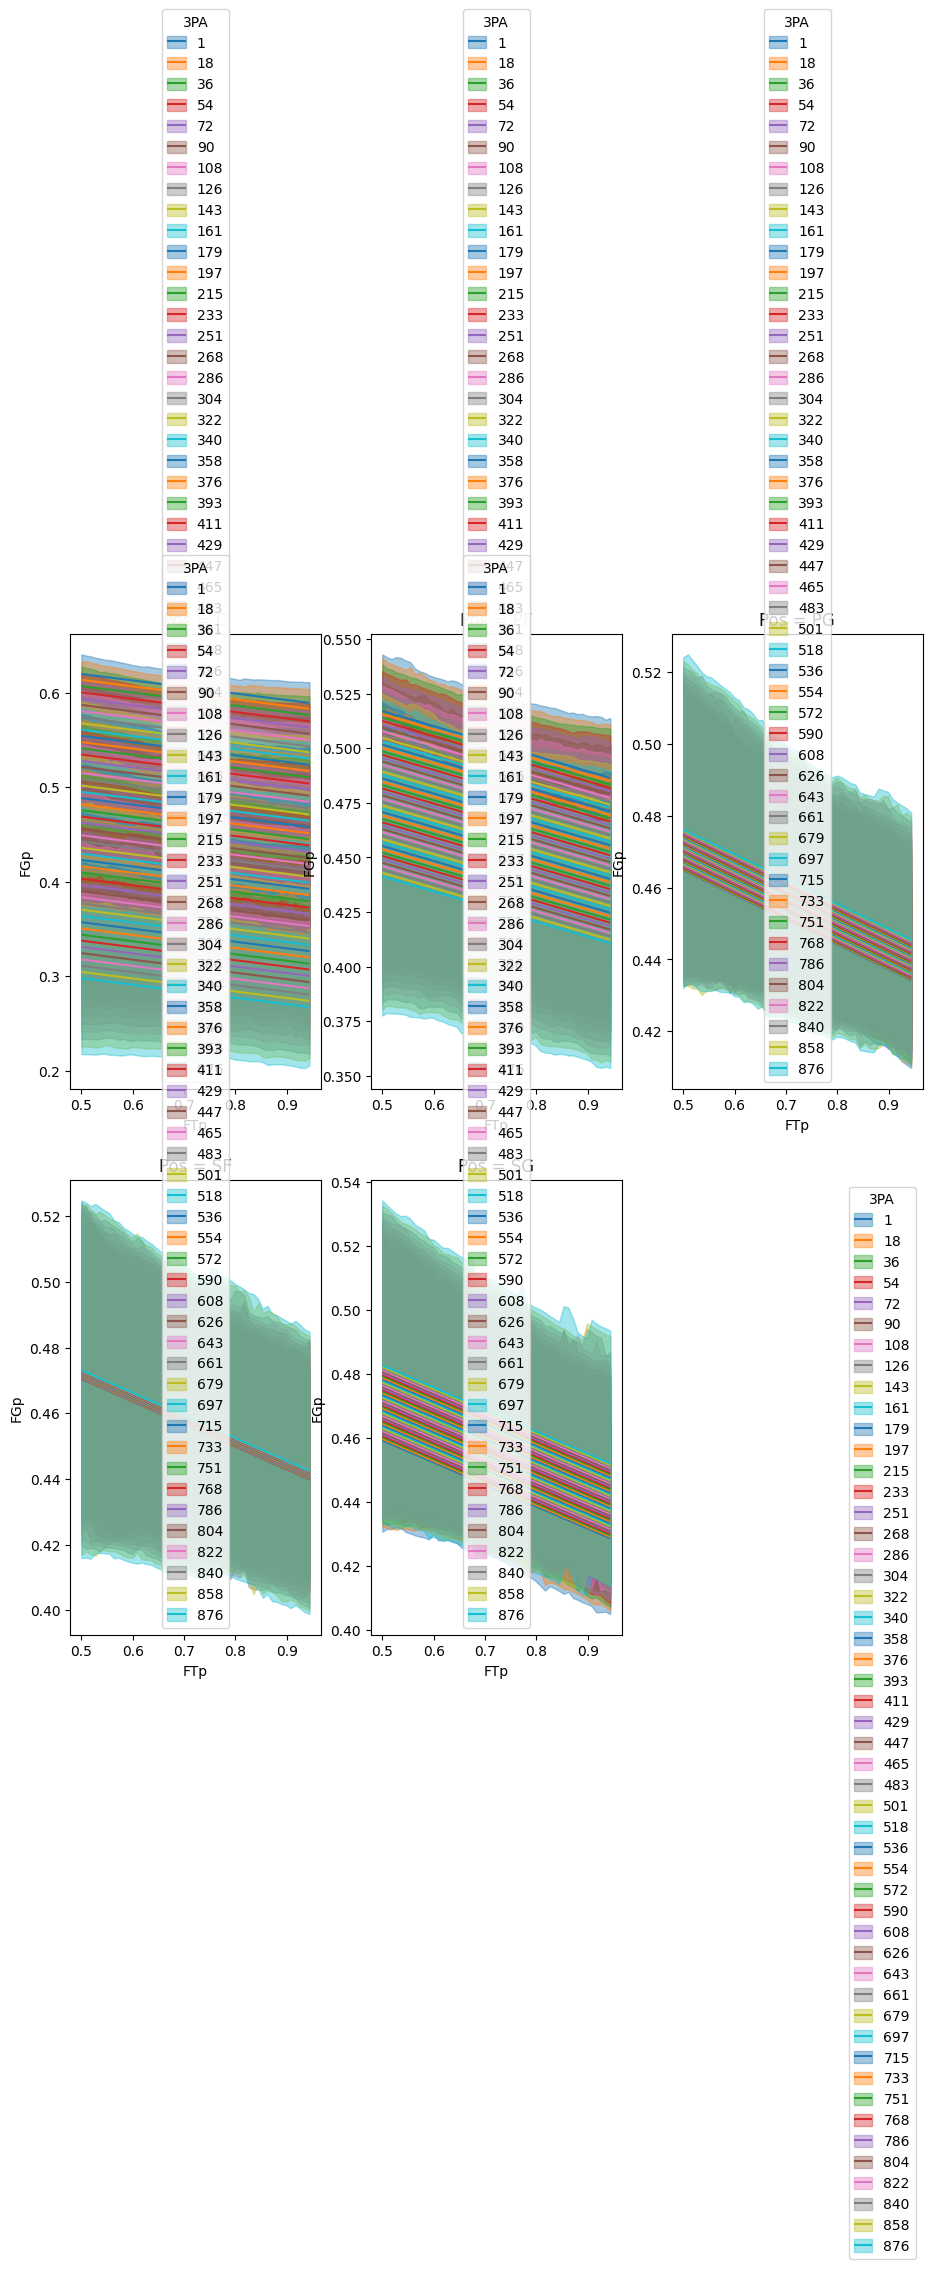

In [15]:
bmb.interpret.plot_predictions(model_bb_inter5,
                               idata_bb_inter5,
                               ["FTp","3PA", "Pos"],
                               fig_kwargs={"figsize":(11, 13)})#,
                               #legend=False)

In [17]:
import arviz as az

cmp_df = az.compare(
    {"1":idata_basketball,"2":idata_basketball_h,"3":idata_bb_inter,"4":idata_bb_inter4, "5":idata_bb_inter5} )
cmp_df

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
5,0,529.843444,12.700618,0.000000,5.893974e-01,15.812759,0.000000,False,log
4,1,529.805710,22.121979,0.037734,4.106026e-01,14.397773,6.086821,True,log
3,2,509.485553,13.718457,20.357891,8.262332e-16,16.707160,7.696010,False,log
2,3,507.663004,14.417157,22.180440,0.000000e+00,17.101463,7.146688,False,log
1,4,507.148654,8.466543,22.694790,0.000000e+00,16.056016,6.789074,False,log


**Task11**:

Which model is "better" according to this metric?

Why do you think that is?

The better model according to this metric is the fourth multi linear model. This is because the fourth multi linear model takes into account all combinations of predictors.

**Task12:**

The body data set has a measure of body fat percentage (siri), as well as several other measurments of other parts of a person's body, plus their age.

Create a sensible causal diagram for this set of variables.

Based on your causal diagram, which variable should you try to predict? Why?

In [18]:
body = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/body_fat.csv')

In [19]:
body.head()

,siri,age,weight,height,abdomen,thigh,wrist
0,12.3,23,70.1,172,85.2,59.0,17.1
1,6.1,22,78.8,184,83.0,58.7,18.2
2,25.3,22,70.0,168,87.9,59.6,16.6
3,10.4,26,84.0,184,86.4,60.1,18.2
4,28.7,24,83.8,181,100.0,63.2,17.7


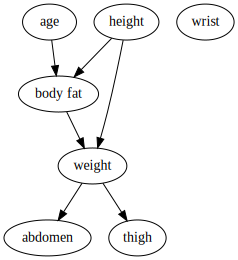

In [20]:
b_dag = gv.Digraph(name="Body DAG")

b_dag.node('F','body fat')
b_dag.node('A','age')
b_dag.node('H','height')
b_dag.node('L','weight')
b_dag.node('S','abdomen')
b_dag.node('T','thigh')
b_dag.node('W','wrist')

b_dag.edges(['AF','FL','LS','LT','HL','HF'])

b_dag


Weight